In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content

!cp /content/drive/MyDrive/MPNet-master.zip .
!unzip -oq MPNet-master.zip

!cp /content/drive/MyDrive/dataset.zip .
!unzip -oq dataset.zip

%cd /content/MPNet-master/MPNet

!sed -i 's/print \"epoch\" + str(epoch)/print(\"epoch\" + str(epoch))/g' AE/CAE.py
!sed -i 's/print \"--average loss:\"/print(\"--average loss:\")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(len(obs)\/args.batch_size)/print(avg_loss\/(len(obs)\/args.batch_size))/g' AE/CAE.py
!sed -i 's/print "--Validation average loss:"/print("--Validation average loss:")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(5000\/args.batch_size)/print(avg_loss\/(5000\/args.batch_size))/g' AE/CAE.py

!grep -n "print " AE/CAE.py

import os
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from AE.CAE import Encoder
from model import MLP


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

encoder = Encoder().to(device)

encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/cae_encoder.pkl",
        map_location=device
    )
)

encoder.eval()
print("Encoder loaded")

pnet = MLP(32, 2).to(device)

pnet.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl",
        map_location=device
    )
)

pnet.eval()
print("MPNet loaded")


DATASET_DIR = "/content/dataset"

obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc1.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

print("obs_code shape:", obs_code.shape)

Mounted at /content/drive
/content
/content/MPNet-master/MPNet
cuda
Encoder loaded
MPNet loaded
obs_code shape: torch.Size([28])


In [2]:
import os
import re

def sorted_case_ids(env_id):
    folder = f"{DATASET_DIR}/e{env_id}"
    files = [
        f for f in os.listdir(folder)
        if re.match(r"path\d+\.dat$", f)
    ]
    ids = sorted(
        int(re.findall(r"\d+", f)[0])
        for f in files
    )
    return ids


In [3]:
for env_id in range(15, 20):
    obs_file = f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat"
    path_folder = f"{DATASET_DIR}/e{env_id}"

    print("Env", env_id)
    print("  obs exists:", os.path.exists(obs_file))
    print("  path folder exists:", os.path.exists(path_folder))

    if os.path.exists(path_folder):
        ids = sorted_case_ids(env_id)
        print("  num paths:", len(ids), "first ids:", ids[:5])


Env 15
  obs exists: True
  path folder exists: True
  num paths: 300 first ids: [0, 1, 2, 3, 4]
Env 16
  obs exists: True
  path folder exists: True
  num paths: 300 first ids: [0, 1, 2, 3, 4]
Env 17
  obs exists: True
  path folder exists: True
  num paths: 300 first ids: [0, 1, 2, 3, 4]
Env 18
  obs exists: True
  path folder exists: True
  num paths: 300 first ids: [0, 1, 2, 3, 4]
Env 19
  obs exists: True
  path folder exists: True
  num paths: 300 first ids: [0, 1, 2, 3, 4]


In [4]:
import os
import re
import numpy as np
import torch

DATASET_DIR = "/content/dataset"


def sorted_case_ids(env_id):
    folder = f"{DATASET_DIR}/e{env_id}"
    files = [
        f for f in os.listdir(folder)
        if re.match(r"path\d+\.dat$", f)
    ]
    ids = sorted(
        int(re.findall(r"\d+", f)[0])
        for f in files
    )
    return ids


def load_obs_xy(env_id):
    obs_file = f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat"
    obs = np.fromfile(obs_file)
    return obs.reshape(-1, 2).astype(np.float32)


def load_expert_path(env_id, case_id):
    path_file = f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
    path = np.fromfile(path_file)
    return path.reshape(-1, 2).astype(np.float32)


def get_obs_code(obs_xy):
    obs_flat = obs_xy.reshape(-1)
    obs_input = torch.from_numpy(obs_flat).float().unsqueeze(0).to(device)

    with torch.no_grad():
        return encoder(obs_input).squeeze(0)


def build_eval_cases(cases_per_env=50, env_ids=range(1, 15)):
    cases = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        ids = sorted_case_ids(env_id)[:cases_per_env]

        for case_id in ids:
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            cases.append({
                "env_id": env_id,
                "case_id": case_id,
                "start": expert_path[0],
                "goal": expert_path[-1],
                "obs_xy": obs_xy,
                "obs_code": obs_code,
                "expert_path": expert_path,
            })

    return cases


In [5]:
reference_cases = build_eval_cases(cases_per_env=50, env_ids=range(1, 15))
generalization_cases = build_eval_cases(cases_per_env=50, env_ids=range(15, 20))

print("reference_cases:", len(reference_cases))
print("generalization_cases:", len(generalization_cases))

print("first reference:", reference_cases[0]["env_id"], reference_cases[0]["case_id"])
print("first generalization:", generalization_cases[0]["env_id"], generalization_cases[0]["case_id"])


reference_cases: 700
generalization_cases: 250
first reference: 1 0
first generalization: 15 0


In [6]:
def generate_goal_bias_path(start, goal, obs_code, alpha=0.0, max_steps=150):
    current = torch.from_numpy(np.asarray(start, dtype=np.float32)).float().to(device)
    goal_t = torch.from_numpy(np.asarray(goal, dtype=np.float32)).float().to(device)

    if not isinstance(obs_code, torch.Tensor):
        obs_code = torch.from_numpy(np.asarray(obs_code, dtype=np.float32)).float().to(device)
    else:
        obs_code = obs_code.float().to(device)

    obs_code = obs_code.view(-1)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            # Correct MPNet input order:
            # obs_code + goal + current = 28 + 2 + 2 = 32
            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)

            pred = pnet(inp).squeeze(0)

            next_state = (1.0 - alpha) * pred + alpha * goal_t

            path.append(next_state.detach().cpu().numpy())
            current = next_state

            if torch.norm(current - goal_t).item() <= GOAL_THRESHOLD:
                break

    return np.asarray(path, dtype=np.float32)


In [7]:
def path_length_np(path):
    path = np.asarray(path, dtype=np.float32)
    if len(path) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1)))


def path_in_collision(path, obs_xy, threshold=0.03, samples_per_segment=20):
    path = np.asarray(path, dtype=np.float32)
    obs_xy = np.asarray(obs_xy, dtype=np.float32).reshape(-1, 2)

    if len(path) < 2:
        return False

    for i in range(len(path) - 1):
        a = path[i]
        b = path[i + 1]

        for s in range(samples_per_segment + 1):
            t = s / samples_per_segment
            p = (1.0 - t) * a + t * b

            d = np.linalg.norm(obs_xy - p, axis=1)
            if np.min(d) < threshold:
                return True

    return False


def evaluate_path(path, goal, obs_xy, expert_path=None):
    path = np.asarray(path, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    if len(path) == 0:
        return {
            "success": False,
            "collision": True,
            "final_dist": float("inf"),
            "path_length": float("inf"),
            "ratio": np.nan,
        }

    final_dist = float(np.linalg.norm(path[-1] - goal))
    collision = path_in_collision(
        path,
        obs_xy,
        threshold=COLLISION_THRESHOLD,
        samples_per_segment=20
    )

    length = path_length_np(path)
    success = (final_dist <= GOAL_THRESHOLD) and (not collision)

    ratio = np.nan
    if expert_path is not None:
        expert_len = path_length_np(expert_path)
        if expert_len > 1e-8:
            ratio = length / expert_len

    return {
        "success": success,
        "collision": collision,
        "final_dist": final_dist,
        "path_length": length,
        "ratio": ratio,
    }


def steer(from_state, to_state, step_size=0.04):
    from_state = np.asarray(from_state, dtype=np.float32)
    to_state = np.asarray(to_state, dtype=np.float32)

    direction = to_state - from_state
    dist = np.linalg.norm(direction)

    if dist <= step_size:
        return to_state

    return from_state + step_size * direction / (dist + 1e-8)


def edge_in_collision(a, b, obs_xy, threshold=0.03, samples=20):
    path = np.asarray([a, b], dtype=np.float32)
    return path_in_collision(
        path,
        obs_xy,
        threshold=threshold,
        samples_per_segment=samples
    )


def rrt_repair(start, goal, obs_xy, max_iter=3000, step_size=0.04, goal_sample_rate=0.20):
    start = np.asarray(start, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    nodes = [start]
    parents = [-1]

    for _ in range(max_iter):
        if random.random() < goal_sample_rate:
            sample = goal
        else:
            sample = np.random.uniform(0.0, 1.0, size=2).astype(np.float32)

        nearest_idx = int(np.argmin([np.linalg.norm(n - sample) for n in nodes]))
        nearest = nodes[nearest_idx]

        new_node = steer(nearest, sample, step_size=step_size)

        if edge_in_collision(nearest, new_node, obs_xy):
            continue

        nodes.append(new_node)
        parents.append(nearest_idx)

        if np.linalg.norm(new_node - goal) <= GOAL_THRESHOLD:
            if not edge_in_collision(new_node, goal, obs_xy):
                nodes.append(goal)
                parents.append(len(nodes) - 2)

                path = []
                idx = len(nodes) - 1

                while idx != -1:
                    path.append(nodes[idx])
                    idx = parents[idx]

                return np.asarray(path[::-1], dtype=np.float32), True

    return np.asarray([start, goal], dtype=np.float32), False


def first_collision_prefix(path, obs_xy):
    path = np.asarray(path, dtype=np.float32)

    if len(path) <= 1:
        return path

    safe = [path[0]]

    for i in range(1, len(path)):
        if edge_in_collision(path[i - 1], path[i], obs_xy):
            break
        safe.append(path[i])

    return np.asarray(safe, dtype=np.float32)


def generate_hybrid_mpnet_path_v3(start, goal, obs_code, obs_xy, max_iter=600):
    coarse_path = generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )

    safe_prefix = first_collision_prefix(coarse_path, obs_xy)
    repair_start = safe_prefix[-1]

    repair_path, repair_success = rrt_repair(
        start=repair_start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=max_iter,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if repair_success and len(repair_path) > 1:
        full_path = np.vstack([safe_prefix, repair_path[1:]])
    else:
        full_path = coarse_path

    return full_path, {
        "repair_success": repair_success,
        "safe_prefix_len": len(safe_prefix),
    }


In [8]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


GOAL_THRESHOLD = 0.10
COLLISION_THRESHOLD = 0.03


def generate_fast_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )


def generate_goal_biased_mpnet_path(start, goal, obs_code):
    return generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.5,
        max_steps=150
    )


def generate_hybrid_for_exp5(start, goal, obs_code, obs_xy):
    path, info = generate_hybrid_mpnet_path_v3(
        start=start,
        goal=goal,
        obs_code=obs_code,
        obs_xy=obs_xy,
        max_iter=600
    )
    return path


def generate_rrt_path(start, goal, obs_xy):
    path, success = rrt_repair(
        start=start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=3000,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if success:
        return path

    return np.asarray([start, goal], dtype=np.float32)


def evaluate_method_on_cases(cases, method_name):
    metrics_all = []

    for case in cases:
        start = case["start"]
        goal = case["goal"]
        obs_xy = case["obs_xy"]
        obs_code = case["obs_code"]
        expert_path = case["expert_path"]

        t0 = time.time()

        if method_name == "Fast MPNet":
            path = generate_fast_mpnet_path(start, goal, obs_code)

        elif method_name == "Goal-biased MPNet":
            path = generate_goal_biased_mpnet_path(start, goal, obs_code)

        elif method_name == "Hybrid MPNet":
            path = generate_hybrid_for_exp5(start, goal, obs_code, obs_xy)

        elif method_name == "RRT":
            path = generate_rrt_path(start, goal, obs_xy)

        else:
            raise ValueError(method_name)

        elapsed = time.time() - t0

        metrics = evaluate_path(path, goal, obs_xy, expert_path)
        metrics["time"] = elapsed
        metrics_all.append(metrics)

    return {
        "method": method_name,
        "total": len(cases),
        "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
        "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
        "avg_time": float(np.mean([m["time"] for m in metrics_all])),
        "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
        "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
        "avg_ratio": float(np.nanmean([m["ratio"] for m in metrics_all])),
    }


def evaluate_generalization(reference_cases, generalization_cases):
    methods = [
        "Fast MPNet",
        "Goal-biased MPNet",
        "Hybrid MPNet",
        "RRT"
    ]

    rows = []

    for split_name, cases in [
        ("Reference Env 1-14", reference_cases),
        ("Generalization Env 15-19", generalization_cases),
    ]:
        for method in methods:
            row = evaluate_method_on_cases(cases, method)
            row["split"] = split_name
            rows.append(row)
            print(row)

    return pd.DataFrame(rows)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

generalization_df = evaluate_generalization(
    reference_cases,
    generalization_cases
)

display(generalization_df)

generalization_df.to_csv(
    "/content/drive/MyDrive/experiment5_generalization_results.csv",
    index=False
)

print("Saved: /content/drive/MyDrive/experiment5_generalization_results.csv")


{'method': 'Fast MPNet', 'total': 700, 'success_rate': np.float64(41.0), 'collision_rate': np.float64(56.85714285714286), 'avg_time': 0.01164278541292463, 'avg_path_length': 0.4757798293126481, 'avg_final_dist': 0.05989128019710604, 'avg_ratio': 0.7919024625345089, 'split': 'Reference Env 1-14'}
{'method': 'Goal-biased MPNet', 'total': 700, 'success_rate': np.float64(44.857142857142854), 'collision_rate': np.float64(55.14285714285714), 'avg_time': 0.001367314202444894, 'avg_path_length': 0.49612093603903695, 'avg_final_dist': 0.03135376453890266, 'avg_ratio': 0.8202879514806722, 'split': 'Reference Env 1-14'}
{'method': 'Hybrid MPNet', 'total': 700, 'success_rate': np.float64(84.42857142857143), 'collision_rate': np.float64(15.571428571428573), 'avg_time': 0.1837394939150129, 'avg_path_length': 0.6445172140880355, 'avg_final_dist': 0.009442230184961643, 'avg_ratio': 1.1045566118040795, 'split': 'Reference Env 1-14'}
{'method': 'RRT', 'total': 700, 'success_rate': np.float64(84.0), 'col

,method,total,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio,split
0,Fast MPNet,700,41.000000,56.857143,0.011643,0.475780,0.059891,0.791902,Reference Env 1-14
1,Goal-biased MPNet,700,44.857143,55.142857,0.001367,0.496121,0.031354,0.820288,Reference Env 1-14
2,Hybrid MPNet,700,84.428571,15.571429,0.183739,0.644517,0.009442,1.104557,Reference Env 1-14
3,RRT,700,84.000000,16.000000,1.172042,0.664725,0.000000,1.089916,Reference Env 1-14
4,Fast MPNet,250,36.400000,59.200000,0.014857,0.477693,0.062751,0.783298,Generalization Env 15-19
5,Goal-biased MPNet,250,40.800000,59.200000,0.001669,0.498381,0.033015,0.812903,Generalization Env 15-19
6,Hybrid MPNet,250,82.000000,18.000000,0.175573,0.671078,0.010488,1.145477,Generalization Env 15-19
7,RRT,250,80.800000,19.200000,1.070418,0.704333,0.000000,1.124596,Generalization Env 15-19


Saved: /content/drive/MyDrive/experiment5_generalization_results.csv


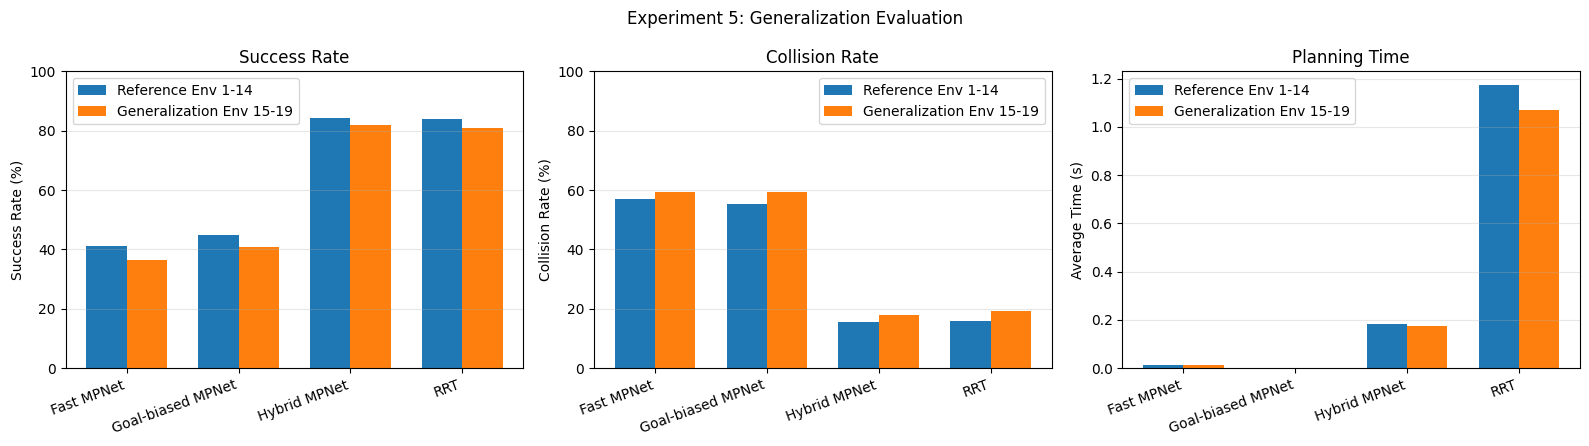

Saved: /content/drive/MyDrive/experiment5_generalization_success_collision_time.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["Fast MPNet", "Goal-biased MPNet", "Hybrid MPNet", "RRT"]

ref_df = generalization_df[generalization_df["split"] == "Reference Env 1-14"].set_index("method").loc[methods]
gen_df = generalization_df[generalization_df["split"] == "Generalization Env 15-19"].set_index("method").loc[methods]

x = np.arange(len(methods))
width = 0.36

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Success rate
axes[0].bar(x - width / 2, ref_df["success_rate"], width, label="Reference Env 1-14")
axes[0].bar(x + width / 2, gen_df["success_rate"], width, label="Generalization Env 15-19")
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_title("Success Rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].set_ylim(0, 100)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# Collision rate
axes[1].bar(x - width / 2, ref_df["collision_rate"], width, label="Reference Env 1-14")
axes[1].bar(x + width / 2, gen_df["collision_rate"], width, label="Generalization Env 15-19")
axes[1].set_ylabel("Collision Rate (%)")
axes[1].set_title("Collision Rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

# Average planning time
axes[2].bar(x - width / 2, ref_df["avg_time"], width, label="Reference Env 1-14")
axes[2].bar(x + width / 2, gen_df["avg_time"], width, label="Generalization Env 15-19")
axes[2].set_ylabel("Average Time (s)")
axes[2].set_title("Planning Time")
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 5: Generalization Evaluation")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment5_generalization_success_collision_time.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


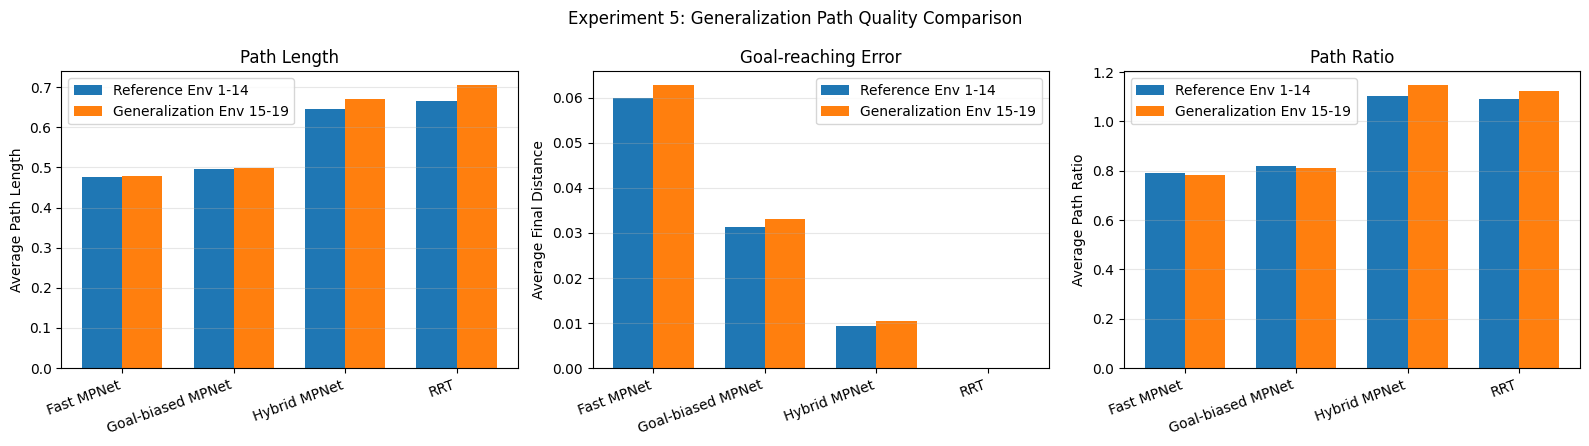

Saved: /content/drive/MyDrive/experiment5_generalization_path_quality.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Average path length
axes[0].bar(x - width / 2, ref_df["avg_path_length"], width, label="Reference Env 1-14")
axes[0].bar(x + width / 2, gen_df["avg_path_length"], width, label="Generalization Env 15-19")
axes[0].set_ylabel("Average Path Length")
axes[0].set_title("Path Length")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# Average final distance
axes[1].bar(x - width / 2, ref_df["avg_final_dist"], width, label="Reference Env 1-14")
axes[1].bar(x + width / 2, gen_df["avg_final_dist"], width, label="Generalization Env 15-19")
axes[1].set_ylabel("Average Final Distance")
axes[1].set_title("Goal-reaching Error")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=20, ha="right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

# Average path ratio
axes[2].bar(x - width / 2, ref_df["avg_ratio"], width, label="Reference Env 1-14")
axes[2].bar(x + width / 2, gen_df["avg_ratio"], width, label="Generalization Env 15-19")
axes[2].set_ylabel("Average Path Ratio")
axes[2].set_title("Path Ratio")
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=20, ha="right")
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 5: Generalization Path Quality Comparison")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment5_generalization_path_quality.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


In [11]:
def evaluate_single_method_case(case, method_name):
    start = case["start"]
    goal = case["goal"]
    obs_xy = case["obs_xy"]
    obs_code = case["obs_code"]
    expert_path = case["expert_path"]

    if method_name == "Fast MPNet":
        path = generate_fast_mpnet_path(start, goal, obs_code)

    elif method_name == "Goal-biased MPNet":
        path = generate_goal_biased_mpnet_path(start, goal, obs_code)

    elif method_name == "Hybrid MPNet":
        path = generate_hybrid_for_exp5(start, goal, obs_code, obs_xy)

    elif method_name == "RRT":
        path = generate_rrt_path(start, goal, obs_xy)

    else:
        raise ValueError(method_name)

    metrics = evaluate_path(path, goal, obs_xy, expert_path)

    return path, metrics


def find_generalization_qualitative_case(cases, max_candidates=10):
    candidates = []

    for case in cases:
        paths = {}
        metrics = {}

        for method in ["Fast MPNet", "Goal-biased MPNet", "Hybrid MPNet", "RRT"]:
            path, m = evaluate_single_method_case(case, method)
            paths[method] = path
            metrics[method] = m

        fast_bad = (not metrics["Fast MPNet"]["success"]) or metrics["Fast MPNet"]["collision"]
        goal_bad = (not metrics["Goal-biased MPNet"]["success"]) or metrics["Goal-biased MPNet"]["collision"]
        hybrid_good = metrics["Hybrid MPNet"]["success"] and (not metrics["Hybrid MPNet"]["collision"])
        rrt_good = metrics["RRT"]["success"] and (not metrics["RRT"]["collision"])

        if fast_bad and goal_bad and hybrid_good and rrt_good:
            # Prefer visually informative cases:
            # large MPNet collision problem + successful repair
            score = (
                metrics["Fast MPNet"]["collision"] * 2
                + metrics["Goal-biased MPNet"]["collision"] * 2
                + metrics["Hybrid MPNet"]["path_length"]
                + metrics["RRT"]["path_length"]
            )

            candidates.append({
                "case": case,
                "paths": paths,
                "metrics": metrics,
                "score": score,
            })

            print(
                "candidate:",
                "env", case["env_id"],
                "case", case["case_id"],
                "| Fast success/collision:",
                metrics["Fast MPNet"]["success"],
                metrics["Fast MPNet"]["collision"],
                "| Goal success/collision:",
                metrics["Goal-biased MPNet"]["success"],
                metrics["Goal-biased MPNet"]["collision"],
                "| Hybrid success:",
                metrics["Hybrid MPNet"]["success"],
                "| RRT success:",
                metrics["RRT"]["success"],
            )

            if len(candidates) >= max_candidates:
                break

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    return candidates


qual_candidates = find_generalization_qualitative_case(
    generalization_cases,
    max_candidates=10
)

print("num candidates:", len(qual_candidates))

best = qual_candidates[0]
print("Best case:")
print("env:", best["case"]["env_id"])
print("case:", best["case"]["case_id"])

for method, m in best["metrics"].items():
    print(method, m)


candidate: env 15 case 2 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 3 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 4 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 5 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 6 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 8 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candidate: env 15 case 9 | Fast success/collision: False True | Goal success/collision: False True | Hybrid success: True | RRT success: True
candid

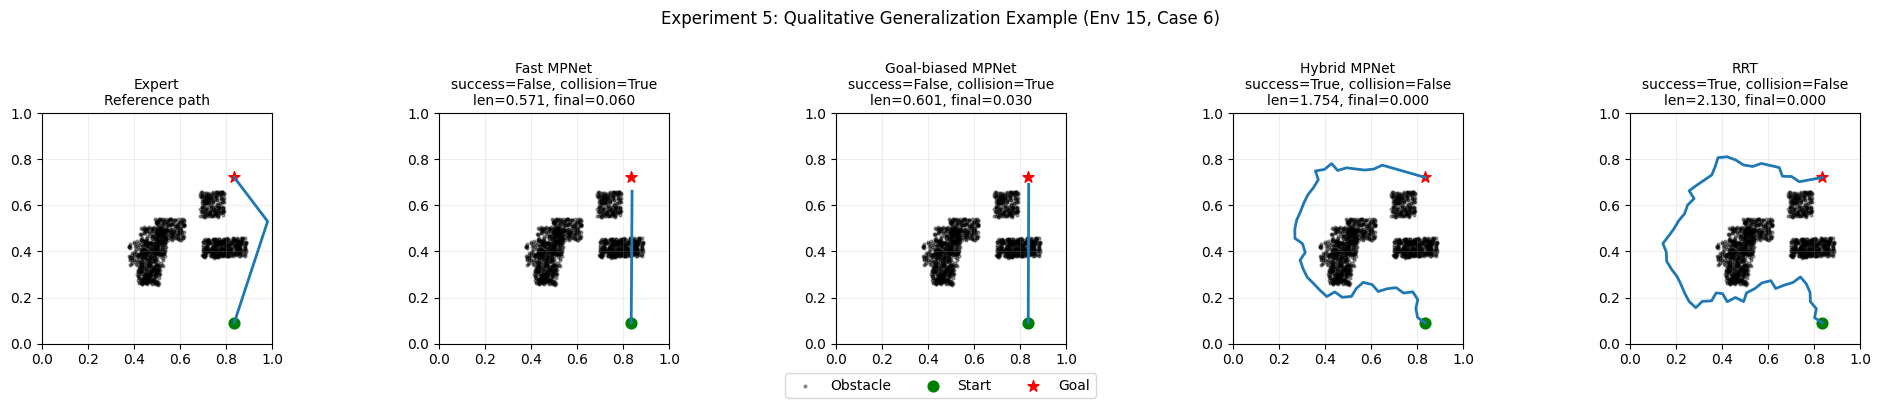

Saved: /content/drive/MyDrive/experiment5_qualitative_generalization_example.png


In [17]:
def plot_generalization_case(candidate, save_path):
    case = candidate["case"]
    paths = candidate["paths"]
    metrics = candidate["metrics"]

    obs_xy = case["obs_xy"]
    expert_path = case["expert_path"]
    start = case["start"]
    goal = case["goal"]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    plot_items = [
        ("Expert", expert_path, None),
        ("Fast MPNet", paths["Fast MPNet"], metrics["Fast MPNet"]),
        ("Goal-biased MPNet", paths["Goal-biased MPNet"], metrics["Goal-biased MPNet"]),
        ("Hybrid MPNet", paths["Hybrid MPNet"], metrics["Hybrid MPNet"]),
        ("RRT", paths["RRT"], metrics["RRT"]),
    ]

    for ax, (title, path, metric) in zip(axes, plot_items):
        ax.scatter(
            obs_xy[:, 0],
            obs_xy[:, 1],
            s=4,
            c="black",
            alpha=0.35,
            label="Obstacle"
        )

        path = np.asarray(path)
        ax.plot(path[:, 0], path[:, 1], linewidth=2)

        ax.scatter(start[0], start[1], c="green", s=60, marker="o", label="Start")
        ax.scatter(goal[0], goal[1], c="red", s=70, marker="*", label="Goal")

        if metric is None:
            subtitle = "Reference path"
        else:
            subtitle = (
                f"success={metric['success']}, "
                f"collision={metric['collision']}\n"
                f"len={metric['path_length']:.3f}, "
                f"final={metric['final_dist']:.3f}"
            )

        ax.set_title(f"{title}\n{subtitle}", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3)

    plt.suptitle(
        f"Experiment 5: Qualitative Generalization Example "
        f"(Env {case['env_id']}, Case {case['case_id']})"
    )

    plt.tight_layout(rect=[0, 0.10, 1, 0.92])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


plot_generalization_case(
    best,
    "/content/drive/MyDrive/experiment5_qualitative_generalization_example.png"
)
